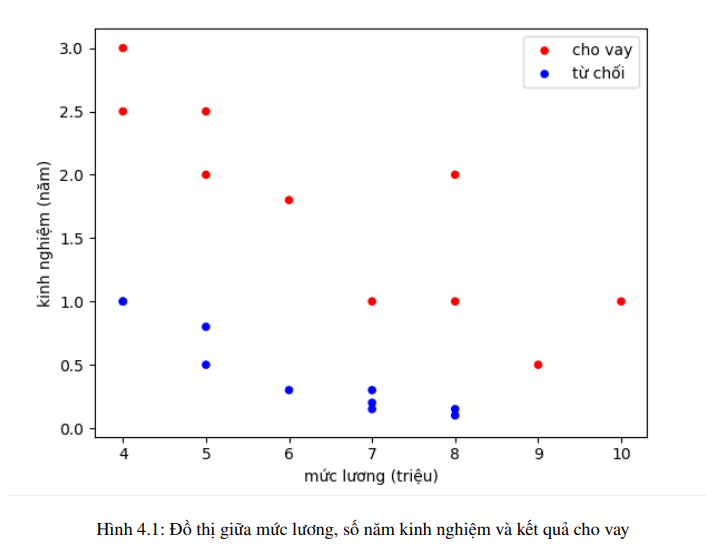

Ví dụ đường xanh là đường phân chia. Dự đoán cho hồ sơ của người có mức lương 6 triệu và 1 năm
kinh nghiệm là không cho vay.

Tuy nhiên, do ngân hàng đang trong thời kỳ khó khăn nên việc cho vay bị thắt lại, chỉ những
hồ sơ nào chắc chắn trên 80% mới được vay.

Vậy nên bây giờ bạn không những tìm là hồ sơ ấy cho vay hay không cho vay mà cần tìm
xác suất nên cho hồ sơ ấy vay là bao nhiêu.

Hay trong nhiều trường hợp khác trong bài toán phân loại người ta quan tâm hơn đến xác suất hay
vì chỉ 1 hay 0. Ví dụ: bác sĩ sẽ thông báo ca mổ này 80% thành công cho người nhà bệnh nhân.


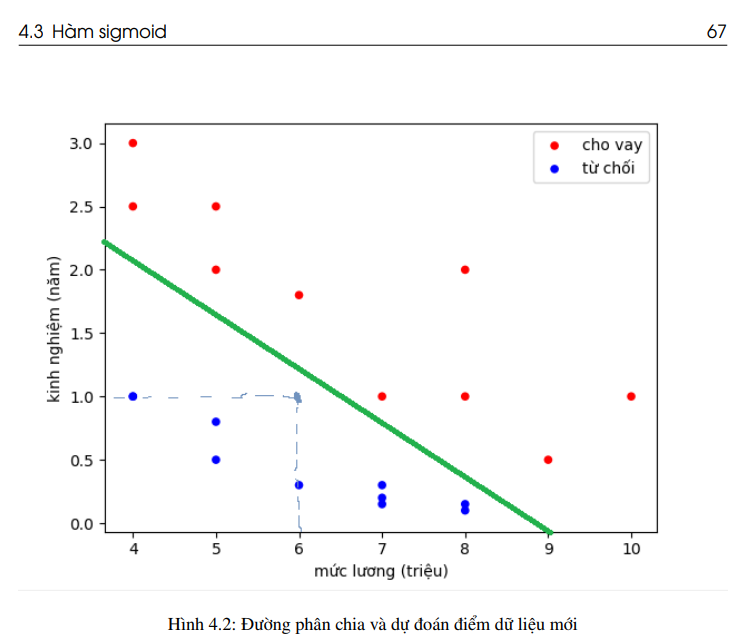

### Tại sao chúng ta cần dùng Xác suất thay vì 0 và 1?

Trong thực tế, mọi thứ không phải lúc nào cũng chỉ có hai màu đen và trắng. Đó là lý do chúng ta cần đến xác suất với các tính chất cơ bản sau:

* **Nằm trong khoảng [0, 1]:** Xác suất không bao giờ âm và cũng không vượt quá 100%.
* **Độ tin cậy:** Sự kiện nào bạn càng chắc chắn xảy ra thì xác suất càng tiến gần về 1. 
    * *Ví dụ:* Nếu bạn có lương cao và thâm niên công tác lâu năm, ngân hàng sẽ đánh giá xác suất bạn trả được nợ là rất cao (ví dụ 0.95), và thế là bạn được duyệt vay mua chung cư.
* **Tính bù trừ:** Tổng xác suất của một sự kiện và sự kiện đối lập của nó luôn bằng 1 (100%).
    * *Ví dụ:* Tung đồng xu thì chỉ có sấp hoặc ngửa. Nếu xác suất ngửa là 50% thì chắc chắn xác suất sấp cũng là 50%. Tổng lại là 100%.

**Ý nghĩa thực tế:**
Xác suất quan trọng hơn việc chỉ đưa ra kết luận "Có" hoặc "Không". Hãy tưởng tượng trước một ca mổ khó, bác sĩ không bao giờ dám khẳng định 100% là "Sống" hay "Chết". Thay vào đó, bác sĩ sẽ nói: *"Xác suất thành công là 80%"*. Con số 80% này giúp chúng ta có cái nhìn khách quan và lường trước được rủi ro tốt hơn nhiều so với việc chỉ nói suông.

Giờ ta cần tìm xác suất của hồ sơ mới nên cho vay. Hay giá trị của hàm cần trong khoảng [0,1]. Rõ
ràng là giá trị của phương trình đường thẳng như bài trước có thể ra ngoài khoảng [0,1] nên cần
một hàm mới luôn có giá trị trong khoảng [0,1]. Đó là hàm sigmoid.

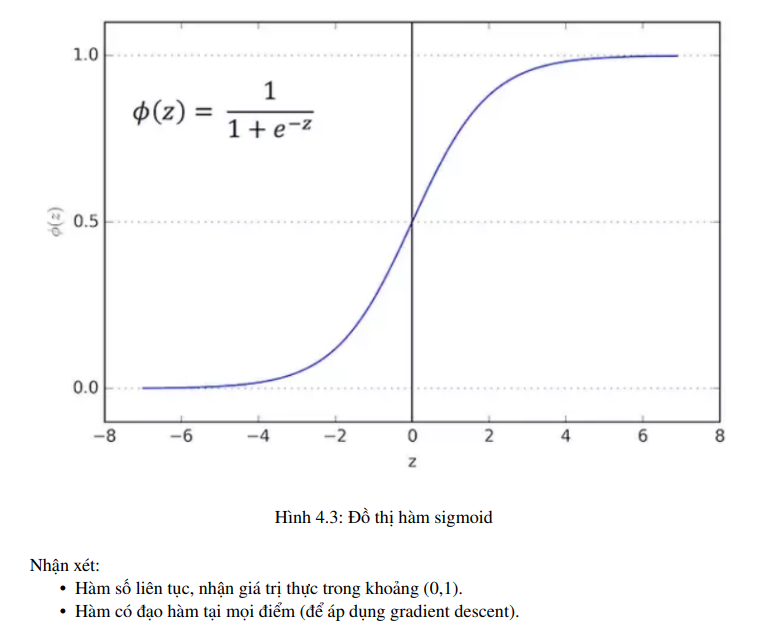

### Thiết lập bài toán
Mọi người có để ý các bước trong bài linear regression không nhỉ, các bước bao gồm:
1. Visualize dữ liệu
2. Thiết lập model
3. Thiết lập loss function
4. Tìm tham số bằng việc tối ưu loss function
5. Dự đoán dữ liệu mới bằng model vừa tìm được
Đây là mô hình chung cho bài toán trong Deep Learning.

### Model



Giả sử với mỗi hồ sơ vay vốn thứ $i$ trong bảng dữ liệu, chúng ta có hai thông tin chính:
* $x_1^{(i)}$: Mức lương.
* $x_2^{(i)}$: Thời gian làm việc.

Mô hình sẽ không trả về kết quả "Cho vay" hay "Từ chối" ngay lập tức, mà trả về **xác suất**:
* $\hat{y}_i = p(x^{(i)} = 1)$: Xác suất mô hình dự đoán hồ sơ này **được** cho vay.
* $1 - \hat{y}_i = p(x^{(i)} = 0)$: Xác suất mô hình dự đoán hồ sơ này **không được** cho vay.
* Tất nhiên: $p(x^{(i)} = 1) + p(x^{(i)} = 0) = 1$.

#### Từ Linear Regression đến Logistic Regression

Nếu như ở bài trước (Linear Regression), công thức dự đoán chỉ đơn giản là một đường thẳng:
$$\hat{y}_i = w_0 + w_1 x_i$$

Thì bây giờ, để biến kết quả thành xác suất (nằm trong khoảng 0 đến 1), chúng ta "bọc" toàn bộ phương trình đường thẳng đó vào trong **hàm Sigmoid**:

$$\hat{y}_i = \sigma(w_0 + w_1 x_1^{(i)} + w_2 x_2^{(i)}) = \frac{1}{1 + e^{-(w_0 + w_1 x_1^{(i)} + w_2 x_2^{(i)})}}$$

**Ý nghĩa:** Việc tính toán $w_0 + w_1 x_1 + w_2 x_2$ vẫn giống như tìm một đường thẳng (hoặc mặt phẳng) phân chia, nhưng hàm Sigmoid đóng vai trò như một "bộ lọc" để chuyển đổi các giá trị thô đó về dạng xác suất giúp chúng ta đưa ra quyết định thông minh hơn.

### Loss function


 Đánh giá mô hình: Hàm Loss Function

Cũng giống như Linear Regression, chúng ta cần một cái thước đo để biết model đang "khôn" hay "dại". Mục tiêu vẫn là làm sao cho giá trị dự đoán $\hat{y}$ càng gần giá trị thật $y$ càng tốt:

* **Nếu thực tế hồ sơ được cho vay ($y_i = 1$):** Ta muốn xác suất dự đoán $\hat{y}_i$ phải thật cao (càng gần 1 càng tốt).
* **Nếu thực tế hồ sơ bị từ chối ($y_i = 0$):** Ta muốn xác suất dự đoán $\hat{y}_i$ phải thật thấp (càng gần 0 càng tốt).

Để hiện thực hóa mong muốn này, chúng ta sử dụng hàm **Binary Cross Entropy**:
$$L = -(y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i))$$

**Lưu ý nhỏ:** Trong Machine Learning hay Deep Learning, khi viết $\log$ thì chúng ta mặc định hiểu đó là logarit tự nhiên ($\ln$).

Nếu hồ sơ thực tế là cho vay (**$y_i = 1$**):
Lúc này phần $(1 - y_i)$ bằng 0, công thức chỉ còn: **$L = -\log(\hat{y}_i)$**
* Nếu $\hat{y}_i$ gần 1 (đoán đúng): $-\log(1) = 0 \Rightarrow$ Mất mát cực nhỏ.
* Nếu $\hat{y}_i$ gần 0 (đoán sai bét): $-\log(\text{số gần 0}) \Rightarrow$ Mất mát sẽ tiến tới dương vô cùng. Model sẽ bị "phạt" rất nặng!

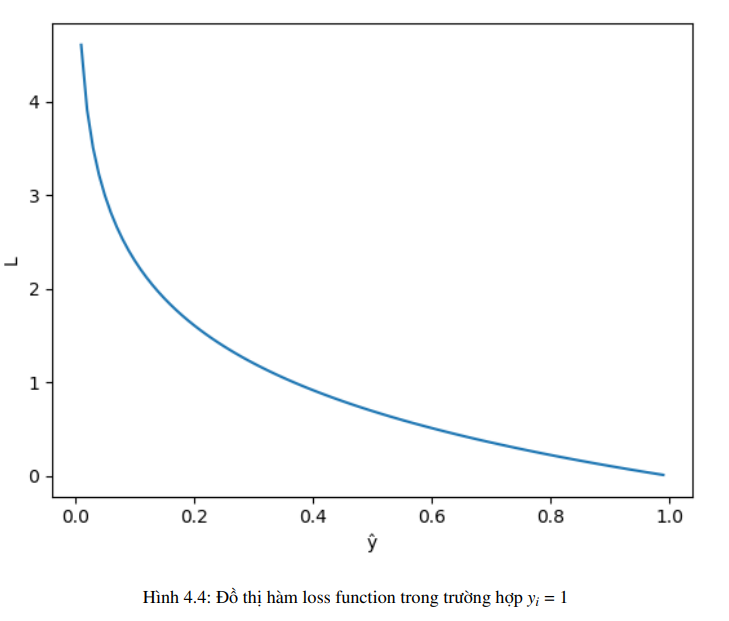

### Nhận xét:
• Hàm L giảm dần từ 0 đến 1.
• Khi model dự đoán yˆi gần 1, tức giá trị dự đoán gần với giá trị thật yi
thì L nhỏ, xấp xỉ 0
• Khi model dự đoán yˆi gần 0, tức giá trị dự đoán ngược lại giá trị thật yi
thì L rất lớn
Ngược lại, nếu yi = 0 => L = −log(1−yˆi)


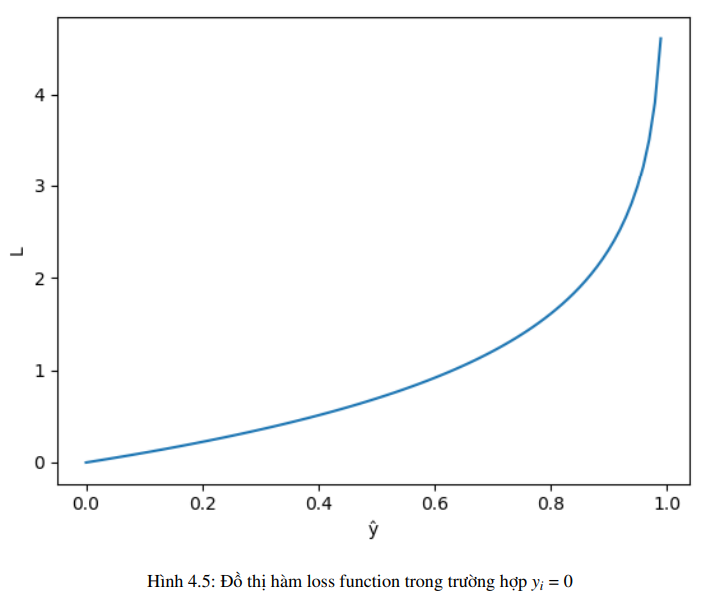

### Nhận xét 

Dựa trên đặc điểm của hàm mất mát $L$:

* **Hàm $L$ tăng dần từ 0 đến 1.**
* **Khi model dự đoán $\hat{y}_i$ gần 0:** Tức là giá trị dự đoán gần với giá trị thật $y_i$ (trong trường hợp $y_i = 0$), khi đó $L$ nhỏ, xấp xỉ 0.
* **Khi model dự đoán $\hat{y}_i$ gần 1:** Tức là giá trị dự đoán ngược lại với giá trị thật $y_i$ (trong trường hợp $y_i = 0$), khi đó $L$ sẽ rất lớn.

**=> Kết luận:** Hàm $L$ có giá trị nhỏ khi model dự đoán gần với giá trị thật và rất lớn khi model dự đoán sai. Nói cách khác, $L$ càng nhỏ thì model dự đoán càng chính xác. Do đó, bài toán huấn luyện model thực chất là bài toán **tìm giá trị nhỏ nhất của $L$**.


Hàm Loss Function trên toàn bộ dữ liệu ($J$)

Công thức tổng quát cho $N$ mẫu dữ liệu:

$$J = -\frac{1}{N} \sum_{i=1}^{N} \left( y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right)$$